# This Jupyter note book aims to use a field measured ERT data from a lake
#### invert the ERT data to interpret the subsurface structure

In [1]:
#import all modules
import pygimli as pg
import matplotlib.pyplot as plt
from pygimli.physics import ert
import pygimli.meshtools as mt

In [2]:
#load data from pygimli web
data = pg.getExampleData("ert/lake.ohm")

29/09/26 - 23:57:17 - pyGIMLi - INFO - Looking for ert/lake.ohm in gimli-org/example-data/


In [3]:
#check what data are here, and what are missing
print(data)

Data: Sensors: 48 data: 658, nonzero entries: ['a', 'b', 'err', 'i', 'm', 'n', 'r', 'u', 'valid']


In [4]:
#check if there is topography 
#plt.plot(pg.x(data), pg.z(data))

In [5]:
#calculate the geometric factor
k_num = ert.createGeometricFactors(data, numerical=True)

29/09/26 - 23:57:17 - pyGIMLi - INFO - Cache /home/jyotirmp/anaconda3/envs/pg/lib/python3.11/site-packages/pygimli/physics/ert/ert.py:createGeometricFactors restored (2.8s x 5): /home/jyotirmp/.cache/pygimli/17392492081337769939


In [6]:
#incorporate geometric factor within the data 
data['k'] = ert.createGeometricFactors(data, numerical=True)
# calculate and incorporate aparent resistivity within data
data['rhoa'] = data['u'] / data ['i'] * data['k']
#now check if the data contains everything
print(data)

29/09/26 - 23:57:17 - pyGIMLi - INFO - Cache /home/jyotirmp/anaconda3/envs/pg/lib/python3.11/site-packages/pygimli/physics/ert/ert.py:createGeometricFactors restored (2.8s x 6): /home/jyotirmp/.cache/pygimli/17392492081337769939


Data: Sensors: 48 data: 658, nonzero entries: ['a', 'b', 'err', 'i', 'k', 'm', 'n', 'r', 'rhoa', 'u', 'valid']


(<Axes: >, <matplotlib.colorbar.Colorbar at 0x7471e6f89b50>)

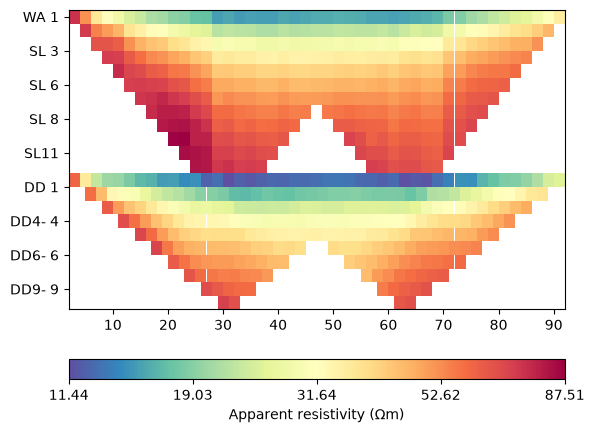

In [7]:
#check the pseudo-section
ert.show(data)

In [8]:
#activate ERT manager and invert data
mgr = ert.ERTManager(data)
mgr.invert(verbose = True, 
           #lam = 50, 
           #zWeight = 0.3
          )
#change parameters, lam, zWeight and check

29/09/26 - 23:57:18 - pyGIMLi - INFO - Found 2 regions.
29/09/26 - 23:57:18 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
29/09/26 - 23:57:18 - pyGIMLi - INFO - Found 2 regions.
29/09/26 - 23:57:18 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
29/09/26 - 23:57:18 - pyGIMLi - INFO - Creating forward mesh from region infos.
29/09/26 - 23:57:18 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
29/09/26 - 23:57:18 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 2001 Cells: 3744 Boundaries: 2936
29/09/26 - 23:57:18 - pyGIMLi - INFO - Use median(data values)=42.69938678956649
29/09/26 - 23:57:18 - pyGIMLi - INFO - Created startmodel from forward operator:732, min/max=42.699387/42.699387
29/09/26 - 23:57:18 - pyGIMLi - INFO - Starting inversion.
29/09/26 - 23:57:18 - pyGIMLi - INFO - fop: <pygimli.physics.ert.ertModelling.ERTModelling object at 0x7471e538d9e0>
29/09/26 - 23:57:18 - pyGIMLi - INFO - Data tran

Constructing Delaunay triangulation by divide-and-conquer method.
Delaunay milliseconds:  0
Recovering segments in Delaunay triangulation.
Segment milliseconds:  0
Removing unwanted triangles.
Spreading regional attributes and area constraints.
Hole milliseconds:  0
Adding Steiner points to enforce quality.
Quality milliseconds:  1

Writing vertices.
Writing triangles.
Writing segments.
Writing edges.

Output milliseconds:  0
Total running milliseconds:  1

Statistics:

  Input vertices: 103
  Input segments: 104
  Input holes: 0

  Mesh vertices: 533
  Mesh triangles: 936
  Mesh edges: 1468
  Mesh exterior boundary edges: 128
  Mesh interior boundary edges: 22
  Mesh subsegments (constrained edges): 150

min/max(dweight) = 20/1000
--------------------------------------------------------------------------------
Calculating response for model: min = 42.6994 max = 42.6994
Allocating memory for primary potential...... 0.0113307

No primary potential for secondary field calculation with to

29/09/26 - 23:57:26 - pyGIMLi - INFO - inv.iter 0 ... chi² = 4058.80
29/09/26 - 23:57:27 - pyGIMLi - INFO - chi² =  525.22 (dPhi = 87.03%) lam: 20.0


322 --------------------------------------------------------------------------------
816 	/ 816 ... 	/ 816
Forward: time: 5.76047s
Response: min = 42.6994 max = 42.6994 mean = 42.6994
Reciprocity rms(modelReciprocity) 0%, max: 0%
min/max(dweight) = 20/1000
Building constraints matrix
constraint matrix of size(nBounds x nModel) 1038 x 732
check Jacobian: wrong dimensions: (0x0) should be (658x732)  force: 1
jacobian size invalid, forced recalc: 1
Calculating Jacobian matrix (forced=1)...Using existing subpotentials for createJacobian.
S(8/6-std::mt): 0.00566403:time: 1.61841s
sens sum: median = 0.997419 min = 0.836082 max = 1.09827
... 1.62265 s
min data = 11.4433 max data = 87.5078 (658)
min error = 0.001 max error = 0.05 (658)
min response = 42.6994 max response = 42.6994 (658)
calc without reference model
0: rms/rrms(data, response) = 17.8576/75.5203%
0: chi^2(data, response, error, log) = 4058.8
0: Phi = 2.67069e+06 + 0 * 20 = 2.67069e+06
solve CGLSCDWWtrans with lambda = 20
Calcula

29/09/26 - 23:57:30 - pyGIMLi - INFO - chi² =  106.65 (dPhi = 79.23%) lam: 20.0


...

29/09/26 - 23:57:35 - pyGIMLi - INFO - chi² =    2.29 (dPhi = 79.00%) lam: 20.0


4: Model: min = 7.70529; max = 272.994
4: Response: min = 11.3741; max = 82.7265
4: rms/rrms(data, Response) = 0.871433/1.51537%
4: chi^2(data, Response, error, log) = 2.29143
4: Phi = 1507.76+94.9252*20=3406.27
--------------------------------------------------------------------------------
inv.iter 5 ... Calculating Jacobian matrix (forced=1)...Using existing subpotentials for createJacobian.
S(8/6-std::mt): 0.00121367:time: 1.44992s
sens sum: median = 2.164 min = 0.957599 max = 3.15444
... 1.45396 s
solve CGLSCDWWtrans with lambda = 20
Calculating response for model: min = 7.6352 max = 266.885
Using existing primary potentials.
Forward: time: 0.501503s
Response: min = 11.3454 max = 85.4881 mean = 42.8301
Reciprocity rms(modelReciprocity) 0.978271%, max: 5.58699%
5: LS newModel: min = 7.6352; max = 266.885
5: LS newResponse: min = 11.37; max = 85.4946
5: rms/rrms(data, LS newResponse) = 0.876746/1.52885%
5: chi^2(data, LS newResponse, error, log) = 2.74707
5: Phi = 1807.57+97.3769*20

29/09/26 - 23:57:38 - pyGIMLi - INFO - chi² =    0.96 (dPhi = 25.17%) lam: 20.0




################################################################################
#                  Abort criterion reached: chi² <= 1 (0.96)                   #
################################################################################


732 [10.433970974275654,...,88.98680487296936]

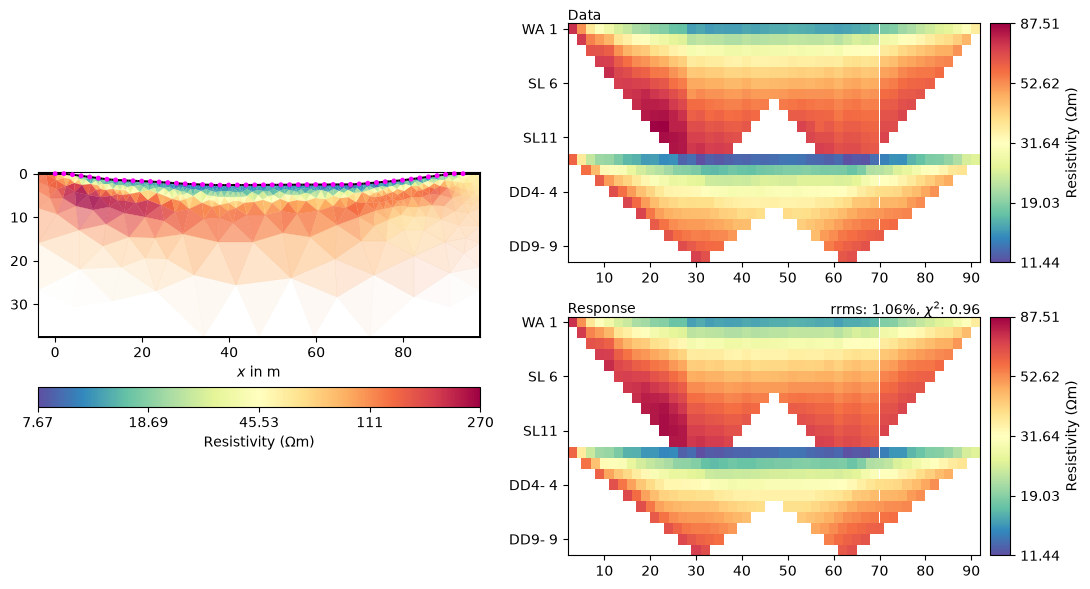

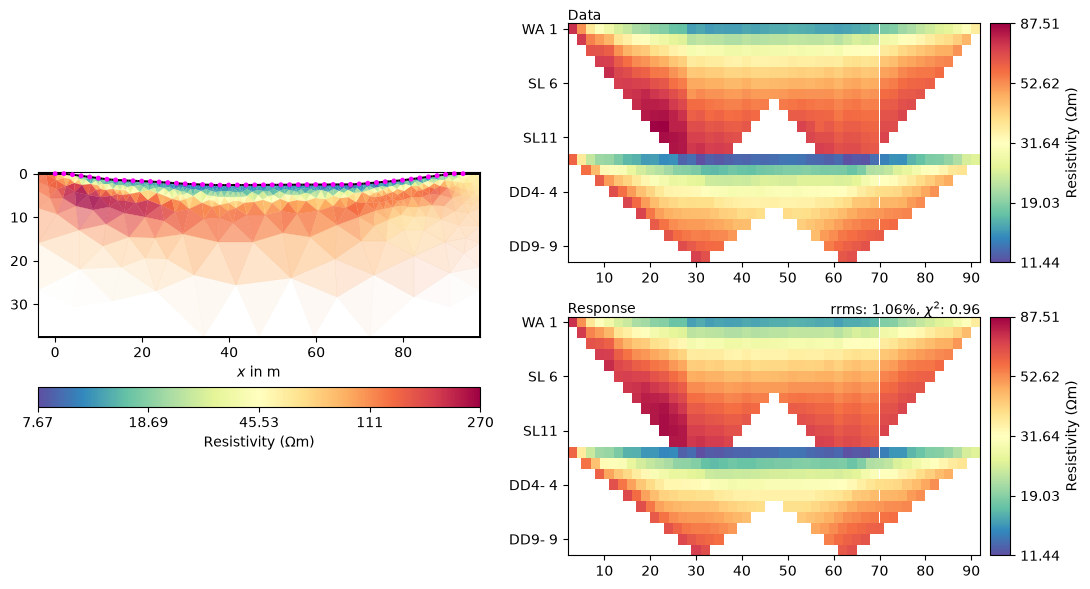

In [9]:
#visualize the data and check the data fitness 
mgr.showResultAndFit()

(<Axes: xlabel='$x$ in m'>, None)

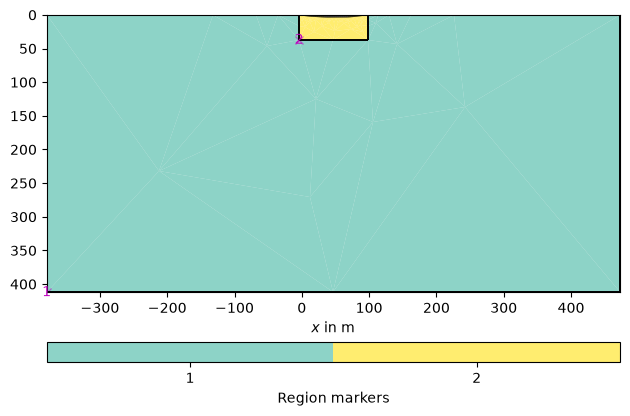

In [10]:
#use geological knowledge to refine the data inversion
geo = mt.createParaMeshPLC(data, depth = -20) #create plc
pg.show(geo)

(<Axes: xlabel='$x$ in m'>, None)

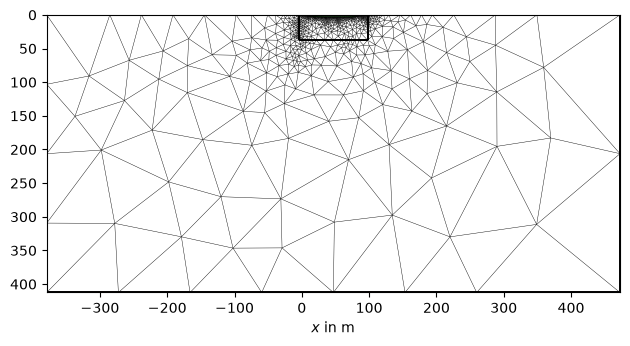

In [11]:
mesh = mt.createMesh(geo, quality = 34) #create mesh
pg.show(mesh)

In [12]:
mgr.setMesh(mesh)

29/09/26 - 23:57:42 - pyGIMLi - INFO - Found 2 regions.
29/09/26 - 23:57:42 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)


Reset region parameter
RegionManager copying mesh ...0.0123809 s 
create NeighborInfos ... 2.1874e-05 s 
analyzing mesh ... 2 regions.
creating para domain ... 0.00499973 s


In [13]:
mgr.invert(verbose = True, lam = 20)

29/09/26 - 23:57:42 - pyGIMLi - INFO - Creating forward mesh from region infos.
29/09/26 - 23:57:42 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.


Found datafile: 48 electrodes
Found: 48 node-electrodes
Found non-Neumann domain
 updateDataDependency:: cleaning primpot
creating para domain ... 0.00759086 s


29/09/26 - 23:57:42 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 3249 Cells: 6216 Boundaries: 4802


ModellingBase::setMesh() copying new mesh ... Found topography for surface=-2.44357 : -2.425


29/09/26 - 23:57:42 - pyGIMLi - INFO - Use median(data values)=42.69938678956649
29/09/26 - 23:57:42 - pyGIMLi - INFO - Created startmodel from forward operator:1027, min/max=42.699387/42.699387
29/09/26 - 23:57:42 - pyGIMLi - INFO - Starting inversion.
29/09/26 - 23:57:42 - pyGIMLi - INFO - fop: <pygimli.physics.ert.ertModelling.ERTModelling object at 0x7471e538d9e0>
29/09/26 - 23:57:42 - pyGIMLi - INFO - Data transformation: Logarithmic LU transform, lower bound 0.0, upper bound 0.0
29/09/26 - 23:57:42 - pyGIMLi - INFO - Model transformation: Logarithmic transform
29/09/26 - 23:57:42 - pyGIMLi - INFO - min/max (data): 11.44/87.51
29/09/26 - 23:57:42 - pyGIMLi - INFO - min/max (error): 0.1%/5%
29/09/26 - 23:57:42 - pyGIMLi - INFO - min/max (start model): 42.7/42.7


...

29/09/26 - 23:58:09 - pyGIMLi - INFO - chi² =    2.43 (dPhi = 73.99%) lam: 20.0
29/09/26 - 23:58:13 - pyGIMLi - INFO - chi² =    1.03 (dPhi = 25.54%) lam: 20.0


--------------------------------------------------------------------------------
inv.iter 5 ... Calculating Jacobian matrix (forced=1)...Using existing subpotentials for createJacobian.
S(8/6-std::mt): 0.00160522:time: 1.94271s
sens sum: median = 2.14914 min = 0.958438 max = 3.14032
... 1.94854 s
solve CGLSCDWWtrans with lambda = 20
Calculating response for model: min = 8.5308 max = 284.741
Using existing primary potentials.
Forward: time: 0.870503s
Response: min = 11.3904 max = 84.417 mean = 42.8034
Reciprocity rms(modelReciprocity) 1.30343%, max: 6.2161%
5: LS newModel: min = 8.5308; max = 284.741
5: LS newResponse: min = 11.3854; max = 84.6349
5: rms/rrms(data, LS newResponse) = 0.758558/1.34883%
5: chi^2(data, LS newResponse, error, log) = 2.02493
5: Phi = 1332.4+97.7754*20=3287.91
Performing line search with tau = 0.53
Calculating response for model: min = 8.59918 max = 281.836
Using existing primary potentials.
Forward: time: 0.888373s
Response: min = 11.3872 max = 83.7813 mean =

29/09/26 - 23:58:18 - pyGIMLi - INFO - chi² =    0.67 (dPhi = 8.50%) lam: 20.0


6: LS newModel: min = 8.58898; max = 284.266
6: LS newResponse: min = 11.3891; max = 84.1991
6: rms/rrms(data, LS newResponse) = 0.518706/1.01239%
6: chi^2(data, LS newResponse, error, log) = 0.671745
6: Phi = 442.009+97.1852*20=2385.71
Performing line search with tau = 0.85
Calculating response for model: min = 8.5926 max = 283.901
Using existing primary potentials.
Forward: time: 0.875333s
Response: min = 11.3937 max = 83.9486 mean = 42.7116
Reciprocity rms(modelReciprocity) 1.3448%, max: 5.83986%
6: Model: min = 8.5926; max = 283.901
6: Response: min = 11.3889; max = 84.1678
6: rms/rrms(data, Response) = 0.514365/1.00312%
6: chi^2(data, Response, error, log) = 0.666922
6: Phi = 438.835+97.0047*20=2378.93


################################################################################
#                  Abort criterion reached: chi² <= 1 (0.67)                   #
################################################################################


1027 [10.513891972810624,...,110.51905222236545]

(<Axes: xlabel='$x$ in m'>, <matplotlib.colorbar.Colorbar at 0x7471e4280b50>)

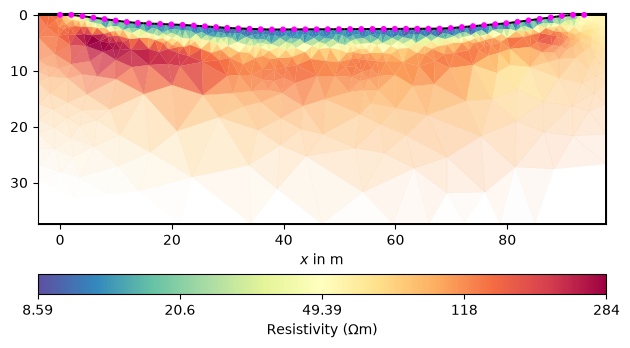

In [14]:
mgr.showResult()